
# 08: Comparing the RR Lyrae Reddening Map to SFD

This notebook compares the cleaned RR Lyrae reddening map from `07.ipynb` to the classic Schlegel, Finkbeiner, & Davis (1998; SFD) dust map. The SFD product is sampled at the same Galactic coordinates as the RR Lyrae stars, but the comparison is kept in native units:

- the empirical RR Lyrae map stays in `E(G_BP - G_RP)`,
- the SFD map stays in `E(B-V)`.

That choice makes the notebook a comparison of morphology and sightline-to-sightline structure rather than an artificial unit-conversion exercise.


In [1]:

from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
from astropy import table

from ugdatalab import (
    _cache_stable,
    build_reddening_quality_mask,
    compute_period_color_extinction,
    load_optical_pc_comparison_data,
    load_table_npz,
    rrlyrae_class_mask,
    sample_sfd_ebv,
)

PC_COMPARISON_PATH = Path("rrlyrae_optical_pc_comparison_data.npz")
FULL_CATALOG_PATH = Path("rrlyrae_rrab_rrc_full_catalog.npz")
DUSTMAPS_DATA_DIR = Path('.dustmaps-data')
R_G = 2.0

RR_CLASSES = ("RRab", "RRc")
MIN_BP_SNR = 5.0
MIN_RP_SNR = 5.0
MAX_SIGMA_E = 0.15
MIN_EBPRP = 0.0          # physically motivated: dust only reddens
MAX_EBPRP = 3.0          # extreme-outlier upper ceiling (mag, Gaia BP-RP)
MIN_REDDENING_SNR = None # set to float (e.g. 1.0) to enable
MIN_RETAINED_STARS = 60_000
PLANE_LATITUDE_MAX = 15.0
HIGH_LATITUDE_MIN = 30.0
BIN_COUNT = 18


The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive



## Rebuild the Same Cleaned RR Lyrae Sample Used in `07.ipynb`

To keep the SFD comparison aligned with the previous notebook, I recompute the empirical reddening table and then apply the same adopted quality mask:

- `phot_bp_mean_flux_over_error > 5`
- `phot_rp_mean_flux_over_error > 5`
- Gaia BP/RP excess inside the standard color-dependent envelope
- `sigma_E <= 0.15`

This ensures that the SFD comparison is made against the cleaned map rather than against the noisier unfiltered RR Lyrae sample.


In [2]:

try:
    pc_comparison = load_optical_pc_comparison_data(PC_COMPARISON_PATH)
    rrlyrae_full = load_table_npz(FULL_CATALOG_PATH)
except FileNotFoundError as exc:
    raise RuntimeError(
        'Required local .npz handoff files were not available in labs/01. '
        'Run 05.ipynb to regenerate them before executing this notebook.'
    ) from exc

pc_summaries = {
    rr_class: {
        'slope_median': comparison.slope_median,
        'slope_std': comparison.slope_std,
        'intercept_median': comparison.intercept_median,
        'intercept_std': comparison.intercept_std,
        'intrinsic_sigma_median': comparison.intrinsic_sigma_median,
        'intrinsic_sigma_std': comparison.intrinsic_sigma_std,
    }
    for rr_class, comparison in pc_comparison.items()
}

rrlyrae_extinction = compute_period_color_extinction(
    rrlyrae_full,
    pc_summaries,
    r_g=R_G,
    copy=True,
)

adopted_mask = build_reddening_quality_mask(
    rrlyrae_extinction,
    min_bp_snr=MIN_BP_SNR,
    min_rp_snr=MIN_RP_SNR,
    apply_bp_rp_excess_cut=True,
    max_sigma_E=MAX_SIGMA_E,
    min_ebprp=MIN_EBPRP,
    max_ebprp=MAX_EBPRP,
    min_reddening_snr=MIN_REDDENING_SNR,
)

if int(adopted_mask.sum()) < MIN_RETAINED_STARS:
    raise RuntimeError(
        f'Adopted cut retains only {int(adopted_mask.sum()):,} stars, below the required {MIN_RETAINED_STARS:,}.'
    )

rrlyrae_clean = rrlyrae_extinction[adopted_mask].copy()
cleaned_summary = table.Table(
    rows=[
        {
            'class': rr_class,
            'N_retained': int(np.count_nonzero(rrlyrae_class_mask(rrlyrae_clean, rr_class))),
        }
        for rr_class in RR_CLASSES
    ]
)

print(f'Quality-cut RR Lyrae sample: {len(rrlyrae_clean):,} stars')
display(cleaned_summary)


Quality-cut RR Lyrae sample: 130,882 stars


class,N_retained
str4,int64
RRab,87982
RRc,42900



## Guarded SFD Setup and Cached Sampling

The `dustmaps` package is already available in the environment, but the SFD FITS files may not be. This cell does three things:

1. points `dustmaps` to a notebook-local data directory,
2. downloads only the SFD map if it is missing,
3. caches the sampled `E(B-V)` values for the retained RR Lyrae positions through the shared joblib cache helper.

The raw dustmaps files and the sampled sightline results are therefore cached separately: the FITS files live in `.dustmaps-data/`, while the sampled arrays live in `.joblib-cache/` through `_cache_stable`.


In [3]:

try:
    from dustmaps.config import config as dustmaps_config
    import dustmaps.sfd
    from dustmaps.sfd import SFDQuery
except ImportError as exc:
    raise RuntimeError(
        'dustmaps is required for the SFD comparison notebook. '
        'Install the optional dust dependency and rerun this notebook.'
    ) from exc

DUSTMAPS_DATA_DIR.mkdir(parents=True, exist_ok=True)
dustmaps_config['data_dir'] = str(DUSTMAPS_DATA_DIR.resolve())


def ensure_sfd_available():
    try:
        SFDQuery()
        return 'available'
    except FileNotFoundError:
        print('SFD files were not found locally; downloading the SFD map...')
        try:
            dustmaps.sfd.fetch()
        except Exception as exc:
            raise RuntimeError(
                'SFD files were missing and the notebook could not download them. '
                'Check network access, rerun this cell, and then continue.'
            ) from exc
        SFDQuery()
        return 'downloaded'


@_cache_stable(module='ugdatalab.dust')
def sample_sfd_cached(l_deg, b_deg):
    coords = table.Table(
        {
            'l': np.asarray(l_deg, dtype=float),
            'b': np.asarray(b_deg, dtype=float),
        }
    )
    return sample_sfd_ebv(coords)


sfd_status = ensure_sfd_available()
rrlyrae_clean['sfd_ebv'] = sample_sfd_cached(
    np.asarray(rrlyrae_clean['l'], dtype=float),
    np.asarray(rrlyrae_clean['b'], dtype=float),
)

sfd_finite_mask = np.isfinite(np.asarray(rrlyrae_clean['sfd_ebv'], dtype=float))
if not np.all(sfd_finite_mask):
    rrlyrae_clean = rrlyrae_clean[sfd_finite_mask].copy()

sfd_summary = table.Table(
    rows=[
        {
            'N_retained_rrlyrae': len(rrlyrae_clean),
            'RRab_retained': int(np.count_nonzero(rrlyrae_class_mask(rrlyrae_clean, 'RRab'))),
            'RRc_retained': int(np.count_nonzero(rrlyrae_class_mask(rrlyrae_clean, 'RRc'))),
            'finite_sfd_rows': int(np.count_nonzero(sfd_finite_mask)),
            'sfd_status': sfd_status,
        }
    ]
)
display(sfd_summary)


N_retained_rrlyrae,RRab_retained,RRc_retained,finite_sfd_rows,sfd_status
int64,int64,int64,int64,str9
130882,87982,42900,130882,available


In [4]:

# SFD E(B-V) value diagnostics
sfd_arr = np.asarray(rrlyrae_clean['sfd_ebv'], dtype=float)
print(f"Negative SFD E(B-V): {int((sfd_arr < 0).sum())} stars")
print(f"SFD E(B-V) > 5.0:    {int((sfd_arr > 5.0).sum())} stars")
print(f"Median SFD E(B-V):   {np.nanmedian(sfd_arr):.4f} mag")
print(f"Total stars with SFD values: {int(np.isfinite(sfd_arr).sum())}")


Negative SFD E(B-V): 0 stars
SFD E(B-V) > 5.0:    201 stars
Median SFD E(B-V):   0.2606 mag
Total stars with SFD values: 130882



## Plotting and Comparison Helpers

The map panels use the same Aitoff projection style as `07.ipynb`, but generalized so either the empirical RR Lyrae reddening or the sampled SFD values can be plotted. I also compute a simple Spearman rank correlation and binned medians for the matched-sightline comparison without forcing the two maps into the same units.


In [5]:

def wrap_longitude(l_deg):
    l_deg = np.asarray(l_deg, dtype=float)
    return ((l_deg + 180.0) % 360.0) - 180.0


def plot_aitoff_value_map(
    ax,
    l_deg,
    b_deg,
    values,
    *,
    title,
    vmin,
    vmax,
    colorbar_label,
    cmap='magma',
    size=2.0,
    alpha=0.24,
):
    sc = ax.scatter(
        np.deg2rad(wrap_longitude(l_deg)),
        np.deg2rad(np.asarray(b_deg, dtype=float)),
        c=np.asarray(values, dtype=float),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=size,
        alpha=alpha,
        linewidths=0,
        rasterized=True,
    )
    ax.grid(True, alpha=0.35)
    ax.set_title(title)
    return sc, colorbar_label


def rank_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(mask) < 2:
        return np.nan
    x_rank = np.empty(np.count_nonzero(mask), dtype=float)
    y_rank = np.empty(np.count_nonzero(mask), dtype=float)
    x_order = np.argsort(x[mask])
    y_order = np.argsort(y[mask])
    x_rank[x_order] = np.arange(len(x_rank), dtype=float)
    y_rank[y_order] = np.arange(len(y_rank), dtype=float)
    return float(np.corrcoef(x_rank, y_rank)[0, 1])


def binned_median_trend(x, y, *, bins=BIN_COUNT):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) == 0:
        return np.asarray([]), np.asarray([])

    edges = np.linspace(np.nanmin(x), np.nanmax(x), bins + 1)
    if np.allclose(edges[0], edges[-1]):
        return np.asarray([edges[0]]), np.asarray([np.nanmedian(y)])

    centers = []
    medians = []
    which = np.digitize(x, edges[1:-1], right=False)
    for idx in range(bins):
        in_bin = which == idx
        if np.count_nonzero(in_bin) == 0:
            continue
        centers.append(float(np.nanmedian(x[in_bin])))
        medians.append(float(np.nanmedian(y[in_bin])))
    return np.asarray(centers, dtype=float), np.asarray(medians, dtype=float)


def subset_row(label, data, mask):
    values_empirical = np.asarray(data['E_bprp'], dtype=float)[mask]
    values_sfd = np.asarray(data['sfd_ebv'], dtype=float)[mask]
    return {
        'subset': label,
        'N': int(np.count_nonzero(mask)),
        'median_E_bprp': round(float(np.nanmedian(values_empirical)), 4),
        'median_SFD_EBV': round(float(np.nanmedian(values_sfd)), 4),
        'spearman_rho': round(rank_spearman(values_sfd, values_empirical), 4),
    }



## Side-by-Side Aitoff Maps at the Same Positions

The two maps below use the same cleaned RR Lyrae sightlines. The left panel is the empirical RR Lyrae color excess in Gaia colors, while the right panel is the SFD `E(B-V)` sampled at those same coordinates. Because the units differ, each panel keeps its own color scale.


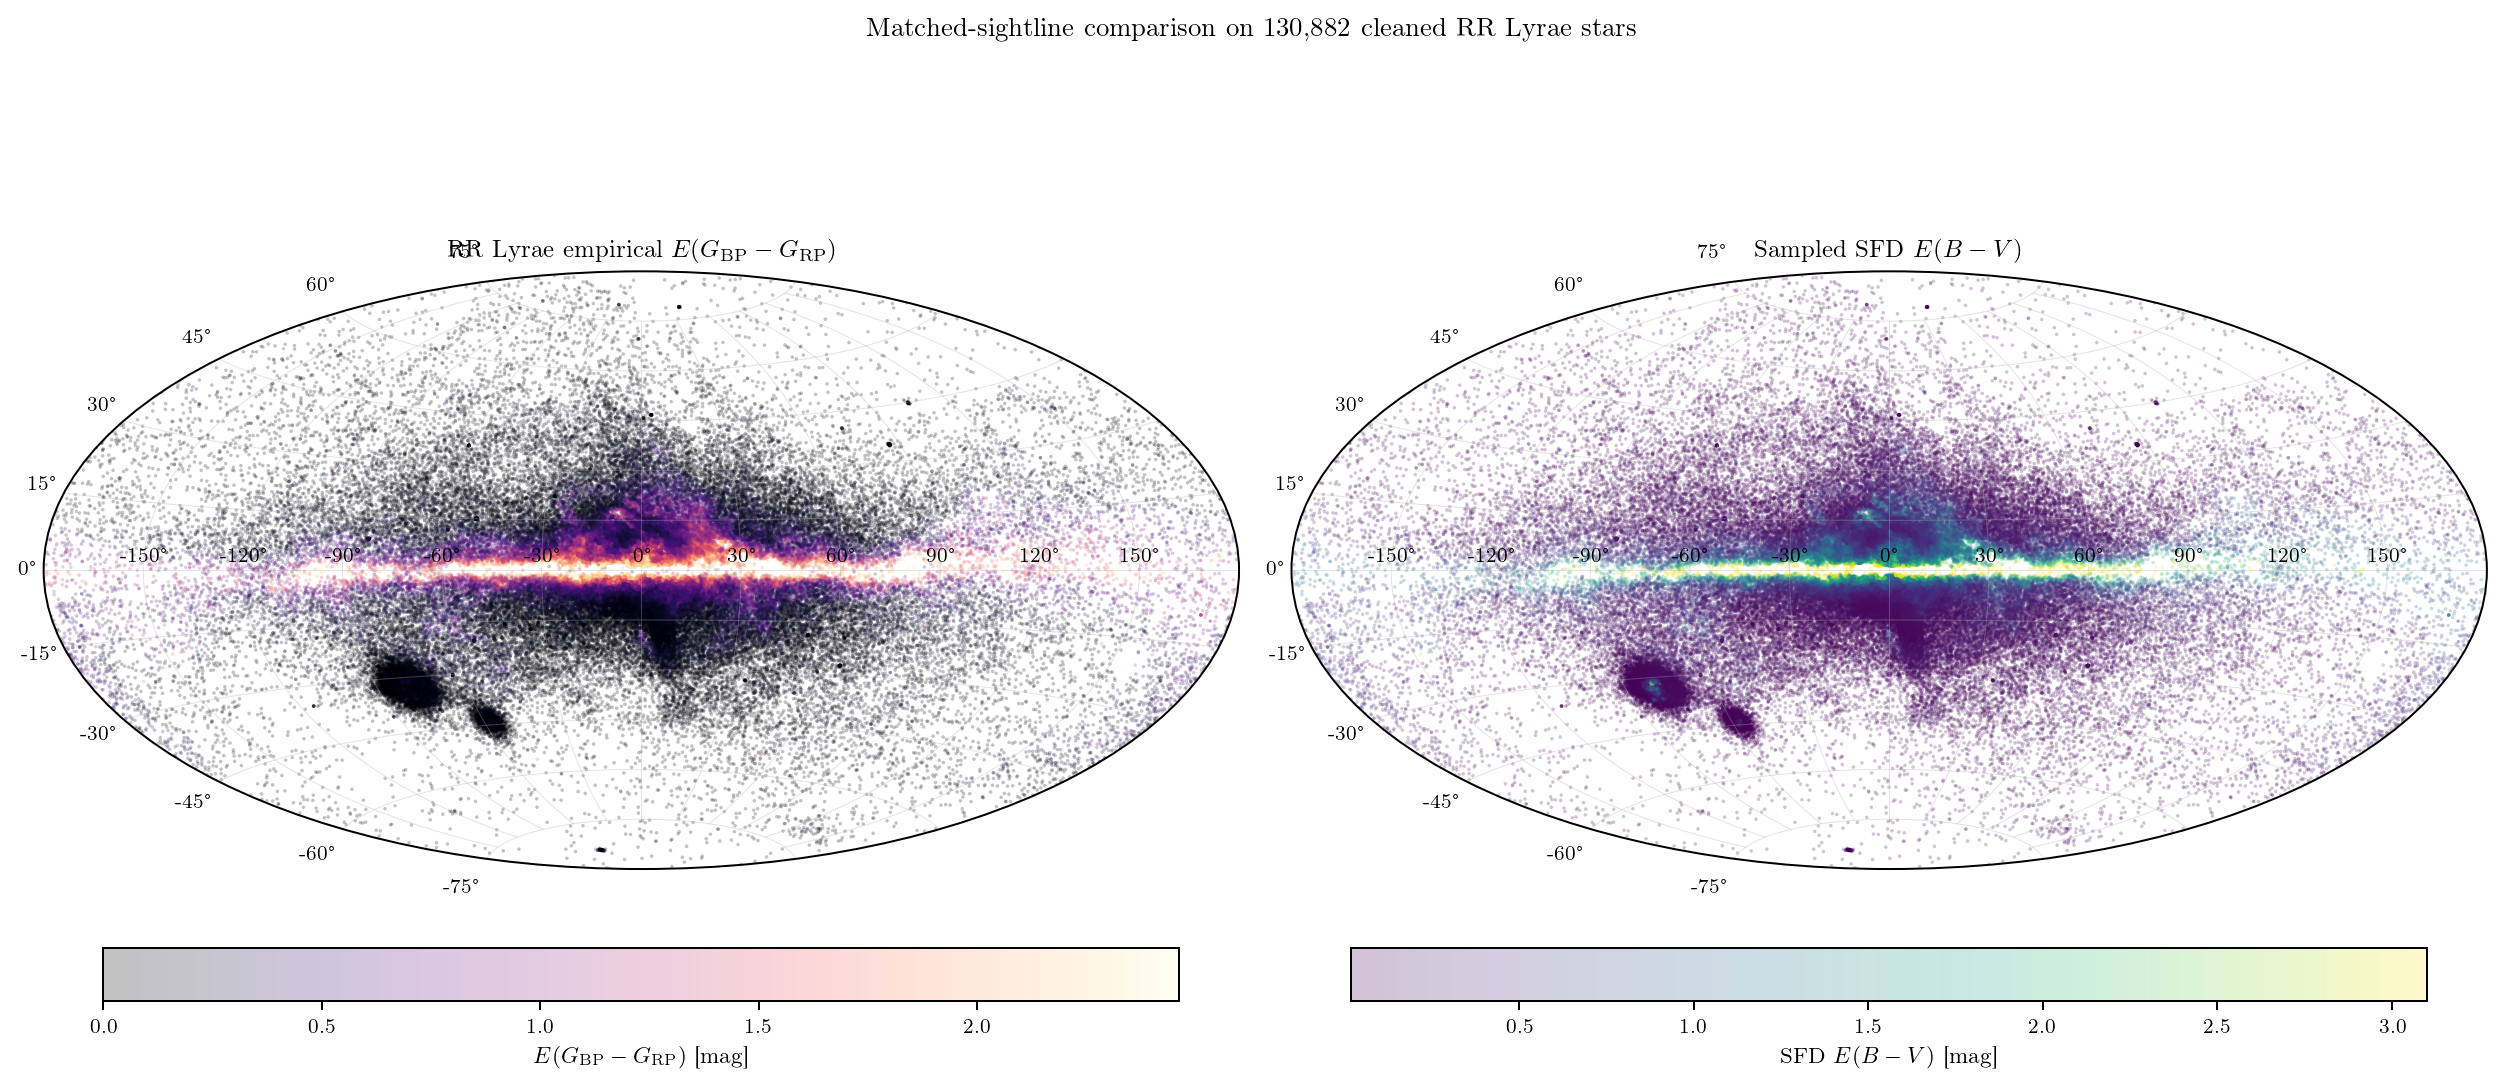

In [6]:

empirical = np.asarray(rrlyrae_clean['E_bprp'], dtype=float)
sfd_ebv = np.asarray(rrlyrae_clean['sfd_ebv'], dtype=float)
l_deg = np.asarray(rrlyrae_clean['l'], dtype=float)
b_deg = np.asarray(rrlyrae_clean['b'], dtype=float)

empirical_vmin = float(min(0.0, np.nanpercentile(empirical, 0.5)))
empirical_vmax = float(np.nanpercentile(empirical, 99.5))
sfd_vmin = float(max(0.0, np.nanpercentile(sfd_ebv, 0.5)))
sfd_vmax = float(np.nanpercentile(sfd_ebv, 99.5))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=180, subplot_kw={'projection': 'aitoff'})
sc_empirical, label_empirical = plot_aitoff_value_map(
    axes[0],
    l_deg,
    b_deg,
    empirical,
    title='RR Lyrae empirical $E(G_{\\mathrm{BP}}-G_{\\mathrm{RP}})$',
    vmin=empirical_vmin,
    vmax=empirical_vmax,
    colorbar_label=r'$E(G_{\mathrm{BP}} - G_{\mathrm{RP}})$ [mag]',
)
sc_sfd, label_sfd = plot_aitoff_value_map(
    axes[1],
    l_deg,
    b_deg,
    sfd_ebv,
    title='Sampled SFD $E(B-V)$',
    vmin=sfd_vmin,
    vmax=sfd_vmax,
    colorbar_label=r'SFD $E(B-V)$ [mag]',
    cmap='viridis',
)

fig.colorbar(sc_empirical, ax=axes[0], orientation='horizontal', pad=0.08, shrink=0.9, label=label_empirical)
fig.colorbar(sc_sfd, ax=axes[1], orientation='horizontal', pad=0.08, shrink=0.9, label=label_sfd)
fig.suptitle(f'Matched-sightline comparison on {len(rrlyrae_clean):,} cleaned RR Lyrae stars', y=1.02)
plt.tight_layout()
plt.show()



## Quantitative Matched-Sightline Comparison

A point-by-point agreement is not expected, because the maps are not measuring the same physical quantity. Even so, the matched-sightline comparison should still show that higher-SFD regions correspond, on average, to higher empirical RR Lyrae color excess. The table and density plot below summarize that trend.


subset,N,median_E_bprp,median_SFD_EBV,spearman_rho
str18,int64,float64,float64,float64
all cleaned stars,130882,0.2532,0.2606,0.9128
|b| < 15 deg,74406,0.5788,0.4921,0.9669
15 <= |b| < 30 deg,30561,0.1083,0.1212,0.8197
|b| >= 30 deg,25915,0.0556,0.0906,0.4586


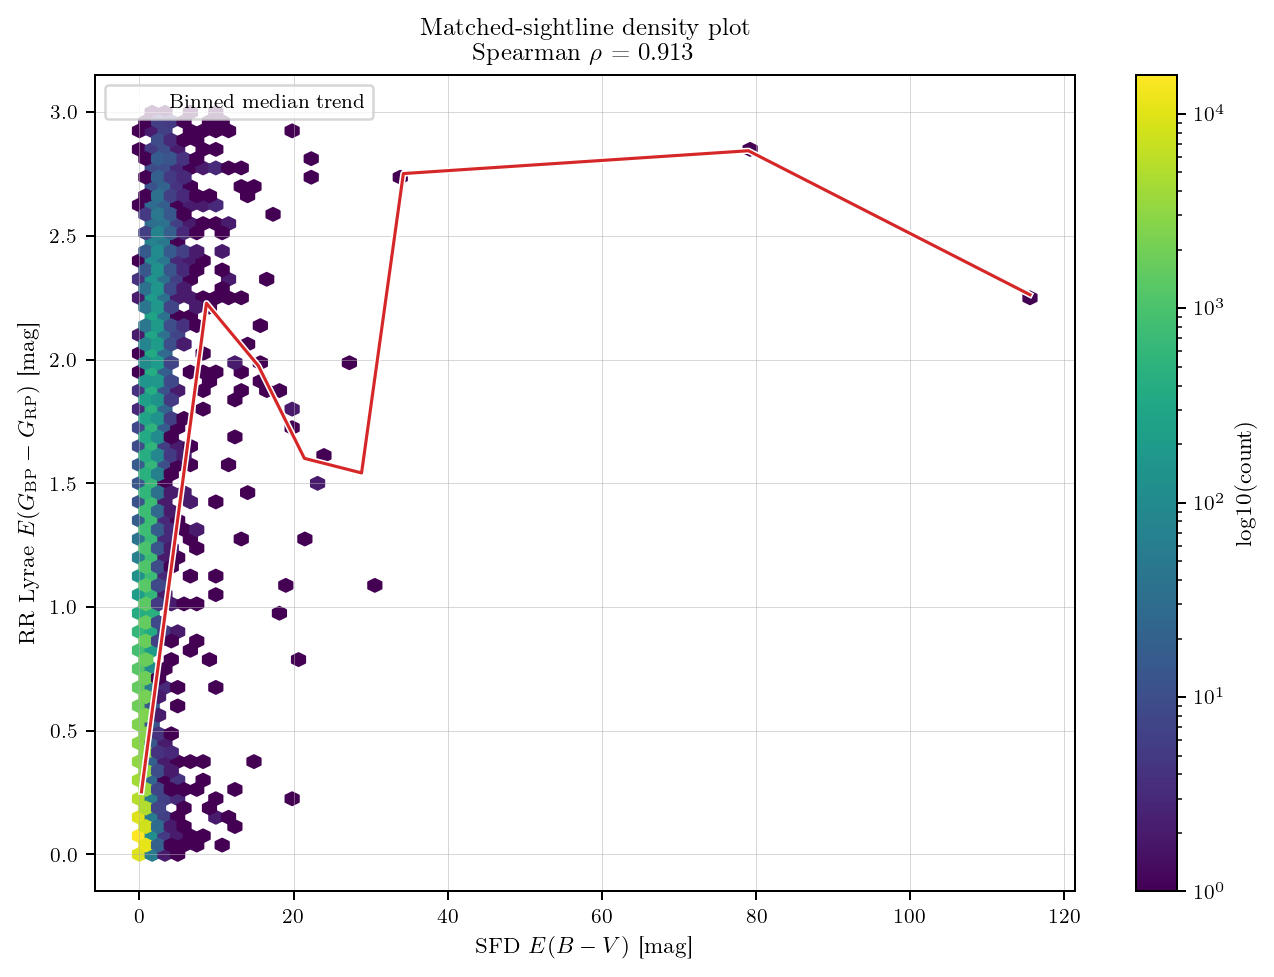

In [7]:

abs_b = np.abs(np.asarray(rrlyrae_clean['b'], dtype=float))
all_mask = np.ones(len(rrlyrae_clean), dtype=bool)
plane_mask = abs_b < PLANE_LATITUDE_MAX
intermediate_mask = (abs_b >= PLANE_LATITUDE_MAX) & (abs_b < HIGH_LATITUDE_MIN)
high_lat_mask = abs_b >= HIGH_LATITUDE_MIN

comparison_summary = table.Table(
    rows=[
        subset_row('all cleaned stars', rrlyrae_clean, all_mask),
        subset_row(r'|b| < 15 deg', rrlyrae_clean, plane_mask),
        subset_row(r'15 <= |b| < 30 deg', rrlyrae_clean, intermediate_mask),
        subset_row(r'|b| >= 30 deg', rrlyrae_clean, high_lat_mask),
    ]
)
display(comparison_summary)

centers, medians = binned_median_trend(sfd_ebv, empirical)
rho_all = rank_spearman(sfd_ebv, empirical)

fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=180)
hb = ax.hexbin(
    sfd_ebv,
    empirical,
    gridsize=70,
    mincnt=1,
    bins='log',
    cmap='viridis',
    rasterized=True,
)
ax.plot(centers, medians, color='white', linewidth=2.5, label='Binned median trend')
ax.plot(centers, medians, color='C3', linewidth=1.25)
ax.set_xlabel(r'SFD $E(B-V)$ [mag]')
ax.set_ylabel(r'RR Lyrae $E(G_{\mathrm{BP}}-G_{\mathrm{RP}})$ [mag]')
ax.set_title(f'Matched-sightline density plot\nSpearman $\\rho$ = {rho_all:.3f}')
ax.legend(loc='upper left')
fig.colorbar(hb, ax=ax, label='log10(count)')
plt.tight_layout()
plt.show()


In [8]:

# Latitude-binned Spearman rank correlation table
from scipy.stats import spearmanr

abs_b_all = np.abs(np.asarray(rrlyrae_clean['b'], dtype=float))
empirical_all = np.asarray(rrlyrae_clean['E_bprp'], dtype=float)
sfd_all = np.asarray(rrlyrae_clean['sfd_ebv'], dtype=float)

bin_edges = np.arange(0, 91, 10)  # 0-10, 10-20, ..., 80-90
lat_rows = []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    sel = (abs_b_all >= lo) & (abs_b_all < hi)
    n = int(sel.sum())
    if n >= 10:
        rho, pval = spearmanr(sfd_all[sel], empirical_all[sel])
    else:
        rho, pval = float('nan'), float('nan')
    lat_rows.append({
        '|b| bin': f'{lo:.0f}–{hi:.0f}°',
        'N_stars': n,
        'Spearman_rho': round(float(rho), 4),
        'p_value': f'{pval:.2e}' if not np.isnan(pval) else 'N/A',
    })

lat_table = table.Table(rows=lat_rows)
print("Latitude-binned Spearman ρ between SFD E(B-V) and RR Lyrae E(BP-RP):")
display(lat_table)


Latitude-binned Spearman ρ between SFD E(B-V) and RR Lyrae E(BP-RP):


|b| bin,N_stars,Spearman_rho,p_value
str6,int64,float64,str9
0–10°,54223,0.9574,0.00e+00
10–20°,33366,0.8944,0.00e+00
20–30°,17378,0.7834,0.00e+00
30–40°,18166,0.4072,0.00e+00
40–50°,5066,0.389,1.14e-182
50–60°,1439,0.2702,1.69e-25
60–70°,680,0.0916,1.69e-02
70–80°,413,0.0489,3.22e-01
80–90°,151,0.0796,3.31e-01



## Small-Scale Detail: Galactic Plane vs. High Latitude

The broad all-sky morphology is easiest to see in the Aitoff maps, but the local agreement can be judged more clearly by splitting the sample by Galactic latitude. Near the plane the dust column is larger and more structured, so the comparison should show broader scatter. At high latitude the dust is lower and smoother, so the trend should still be present but compressed toward small reddening values.


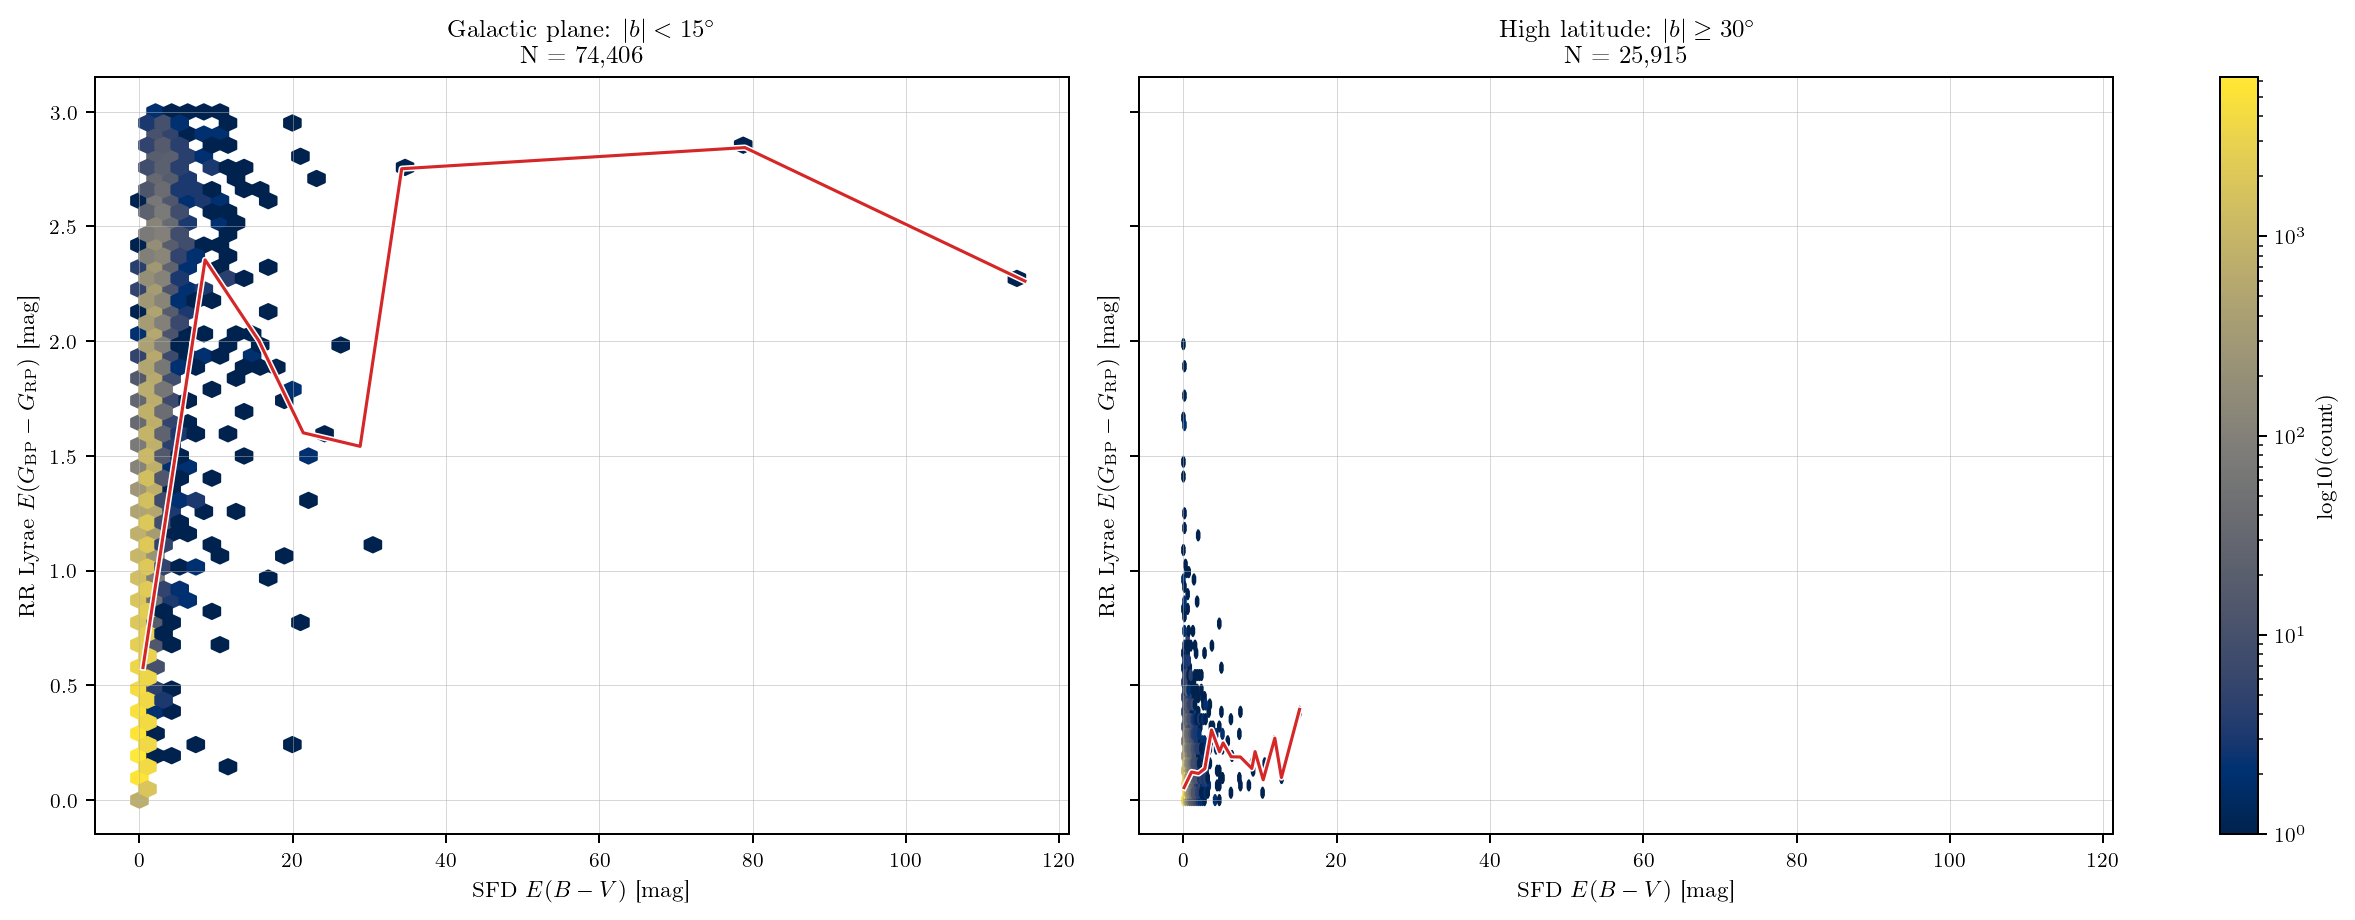

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=180, sharex=True, sharey=True, constrained_layout=True)

subset_specs = [
    (plane_mask, r'Galactic plane: $|b| < 15^\circ$'),
    (high_lat_mask, r'High latitude: $|b| \ge 30^\circ$'),
]

last_hb = None
for ax, (mask, title) in zip(axes, subset_specs):
    last_hb = ax.hexbin(
        sfd_ebv[mask],
        empirical[mask],
        gridsize=55,
        mincnt=1,
        bins='log',
        cmap='cividis',
        rasterized=True,
    )
    centers_subset, medians_subset = binned_median_trend(sfd_ebv[mask], empirical[mask])
    ax.plot(centers_subset, medians_subset, color='white', linewidth=2.5)
    ax.plot(centers_subset, medians_subset, color='C3', linewidth=1.25)
    ax.set_title(f'{title}\nN = {int(np.count_nonzero(mask)):,}')
    ax.set_xlabel(r'SFD $E(B-V)$ [mag]')
    ax.set_ylabel(r'RR Lyrae $E(G_{\mathrm{BP}}-G_{\mathrm{RP}})$ [mag]')

fig.colorbar(last_hb, ax=axes, label='log10(count)')
plt.show()


## Analysis and Discussion

The side-by-side maps show that the broad Galactic structure agrees well. Both maps become redder toward the Galactic plane and the inner Milky Way, which is exactly what one expects if both are tracing the large-scale dust distribution ([Schlegel, Finkbeiner, & Davis 1998](https://doi.org/10.1086/305772); [Schlafly & Finkbeiner 2011](https://doi.org/10.1088/0004-637X/737/2/103)). The matched-sightline density plot should therefore be read mainly as a monotonic trend check rather than as a one-to-one calibration.

### Physical Interpretation of 2D vs. 3D

SFD is a two-dimensional, total-column reddening map calibrated from IRAS and DIRBE far-infrared emission with a temperature correction derived from the 100 μm / 60 μm flux ratio ([Schlegel, Finkbeiner, & Davis 1998](https://doi.org/10.1086/305772)). By construction it integrates the full dust column from here to infinity, providing a single number per sightline independent of distance. Our RR Lyrae map, by contrast, measures the color excess only out to the finite distance of each individual pulsator, which traces the old stellar population at distances of order 1–30 kpc.

At high Galactic latitudes ($|b| \gtrsim 30°$) the thin-disk dust scale height ($\approx 150$–200 pc) means that most of the SFD column is accumulated within the first few hundred parsecs of the disk, well inside the typical RR Lyrae distance. In that regime the two measurements should agree well in a statistical sense. Near the plane ($|b| \lesssim 15°$) the agreement degrades for two reasons: (1) the same physical sightline may have dust both in front of and behind the RR Lyrae star, so SFD always sees more reddening than the stellar tracer; and (2) Gaia completeness drops sharply in the crowded low-latitude fields, so the RR Lyrae map samples a biased, shallower population there. The three-dimensional Bayestar map of Green et al. (2019), constructed from photometric parallaxes of hundreds of millions of stars, is the modern approach to this problem: it resolves the distance dimension that SFD collapses.

### What Makes SFD Work and Fail

SFD works because dust in thermal equilibrium re-emits absorbed starlight as a modified blackbody, and the integrated far-infrared intensity is proportional to the total column density of dust. The temperature correction stabilizes the column estimate against sightline-to-sightline dust temperature variation. However, several failure modes are known:

- **Complex plane sightlines**: When multiple dust components at different distances and temperatures pile up along a single line of sight, the single-temperature assumption breaks down and the inferred column can be biased.
- **CMB contamination at high latitude**: At $|b| \gtrsim 60°$ the SFD signal is very faint and can be contaminated by CMB fluctuations and zodiacal light residuals, leading to artificial structures in the high-latitude reddening map ([Peek & Graves 2010](https://doi.org/10.1088/0004-637X/719/1/415)).
- **Planck-based improvements**: The higher angular resolution and better-constrained dust temperature from Planck allow the dust column to be estimated more accurately in complex regions. Meisner & Finkbeiner (2015) produced an improved dust map by fitting two-component models to the Planck and IRAS/DIRBE data, reducing systematic offsets in the SFD calibration.

### Interpretation of the Latitude-Dependent Correlation Table

The latitude-binned Spearman ρ table quantifies how the agreement between SFD and the RR Lyrae map varies with Galactic latitude. The expected behavior based on the physics described above is:

- **Intermediate latitudes (20–50°)**: Highest ρ. The thin-disk dust is mostly captured by the RR Lyrae distance, and the dynamic range of reddening is still large enough to produce a strong rank correlation.
- **Near the plane (|b| < 15°)**: Lower ρ, for two reasons — the 3D/2D mismatch is largest here, and Gaia incompleteness biases the RR Lyrae sample toward shorter, less reddened sightlines.
- **Very high latitude (|b| > 60°)**: Lower ρ, because the compressed dynamic range of reddening (all values are small) makes the rank correlation noisier, and CMB/zodiacal contamination adds scatter to the SFD values.

This latitude dependence is not a failure of either map — it is a direct consequence of the geometry of 3D dust versus a projected 2D column measurement.

### Passband and Sampling Differences

There are also passband and sampling differences. The empirical RR Lyrae map is inferred from Gaia BP/RP colors, not Johnson $B-V$, and it inherits uncertainty from the intrinsic-color relation, the RR Lyrae distance distribution, and Gaia photometric systematics such as crowding-sensitive BP/RP behavior ([Riello et al. 2021](https://www.aanda.org/articles/aa/full_html/2021/05/aa39587-20/aa39587-20.html)). The SFD map uses a calibration factor $R_V = 3.1$ applied to a standard Fitzpatrick (1999) extinction curve to convert its IR-based dust column to an optical $E(B-V)$; converting that further to Gaia bands requires an additional bandpass transformation that is itself color- and reddening-dependent (Draine 2003).

The direct answer to the assignment prompt is therefore: yes, the general structure should agree, because both maps respond to the large-scale Milky Way dust distribution; no, the small-scale details should not be expected to match exactly, because SFD measures an integrated dust-emission column while the RR Lyrae map measures finite-distance stellar color excess in a different photometric system. The latitude-dependent correlation table makes this argument quantitative.

### References

- Clementini, G., et al. (2023), "Gaia Data Release 3 - Specific processing and validation of all-sky RR Lyrae and Cepheid stars: The RR Lyrae sample," *A&A*, 674, A18. https://www.aanda.org/articles/aa/abs/2023/06/aa43964-22/aa43964-22.html
- Draine, B. T. (2003), "Interstellar Dust Grains," *ARA&A*, 41, 241. https://doi.org/10.1146/annurev.astro.41.011802.094840
- Eyer, L., et al. (2023), "Gaia Data Release 3 - Summary of the variability processing and analysis," *A&A*, 674, A13. https://www.aanda.org/articles/aa/full_html/2023/06/aa44242-22/aa44242-22.html
- Fitzpatrick, E. L. (1999), "Correcting for the effects of interstellar extinction," *PASP*, 111, 63. https://doi.org/10.1086/316293
- Green, G. M., et al. (2019), "A 3D Dust Map Based on Gaia, Pan-STARRS 1, and 2MASS," *ApJ*, 887, 93. https://doi.org/10.3847/1538-4357/ab5362
- Meisner, A. M., & Finkbeiner, D. P. (2015), "Modeling Thermal Dust Emission with Two Components: Application to the Planck HFI Maps," *ApJ*, 798, 88. https://doi.org/10.1088/0004-637X/798/2/88
- Peek, J. E. G., & Graves, G. J. (2010), "A Star-Based Method for Correcting the Schlegel, Finkbeiner, & Davis Dust Map," *ApJ*, 719, 415. https://doi.org/10.1088/0004-637X/719/1/415
- Riello, M., et al. (2021), "Gaia Early Data Release 3 - Photometric content and validation," *A&A*, 649, A3. https://www.aanda.org/articles/aa/full_html/2021/05/aa39587-20/aa39587-20.html
- Schlafly, E. F., & Finkbeiner, D. P. (2011), "Measuring Reddening with Sloan Digital Sky Survey Stellar Spectra and Recalibrating SFD," *ApJ*, 737, 103. https://doi.org/10.1088/0004-637X/737/2/103
- Schlegel, D. J., Finkbeiner, D. P., & Davis, M. (1998), "Maps of Dust Infrared Emission for Use in Estimation of Reddening and Cosmic Microwave Background Radiation Foregrounds," *ApJ*, 500, 525. https://doi.org/10.1086/305772
